### Cell 1：匯入套件

In [1]:
import json
import time
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point
from pykrige.ok import OrdinaryKriging
from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

import rasterio
from rasterio.transform import from_bounds

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120


### Cell 2：檔案路徑設定

In [2]:
# 請改成你的實際檔案路徑
EVENT1_NAME = "event1_2511_Typhoon_Fung-wong"
EVENT2_NAME = "event2_221029_heavy_rain"

EVENT1_JSON = "data\\鳳凰_20251111.csv"
EVENT2_JSON = "data\\豪雨_20250728.csv"

# 若之後要做 zonal stats 或行政區裁切可再用
TOWNSHIP_SHP = r"C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week2_shelter_csv\data\縣市界線(TWD97經緯度)\COUNTY_MOI_1090820.shp"

### Cell 3：資料解析函式

In [3]:
def normalize_cwa_json(data):
    if isinstance(data, dict) and "records" in data:
        return data["records"]
    return data

def parse_rainfall_json(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = pd.read_csv(f)

    data = normalize_cwa_json(data)

    stations = []
    for i in range(len(data)):
        try:
            station_name = data.iloc[i]["StationName"]
            county_name = data.iloc[i]["CountyName"]

            lon = float(data.iloc[i]["StationLongitude"])
            lat = float(data.iloc[i]["StationLatitude"])
            rain = float(data.iloc[i]["Past24hr"])

            stations.append({
                "station_name": station_name,
                "county_name": county_name,
                "lon": lon,
                "lat": lat,
                "rain_24hr": rain
            })
        except Exception:
            continue

    df = pd.DataFrame(stations)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )
    return gdf

### Cell 4：事件資料前處理

篩選花蓮縣與宜蘭縣、移除 -998 與 0、並轉成 EPSG:3826。

In [4]:
TARGET_COUNTIES = ["花蓮縣", "宜蘭縣"]

def prepare_event(filepath, event_name):
    gdf = parse_rainfall_json(filepath).copy()

    # 篩選花蓮 + 宜蘭
    if "county_name" in gdf.columns:
        gdf = gdf[gdf["county_name"].isin(TARGET_COUNTIES)].copy()

    # 過濾異常值
    gdf = gdf[(gdf["rain_24hr"] != -998) & (gdf["rain_24hr"] > 0)].copy()

    # 轉投影
    gdf = gdf.to_crs("EPSG:3826")

    gdf["event_name"] = event_name
    return gdf.reset_index(drop=True)

gdf1 = prepare_event(EVENT1_JSON, EVENT1_NAME)
gdf2 = prepare_event(EVENT2_JSON, EVENT2_NAME)

print(EVENT1_NAME, len(gdf1))
print(EVENT2_NAME, len(gdf2))

display(gdf1.head())
display(gdf2.head())

event1_2511_Typhoon_Fung-wong 168
event2_221029_heavy_rain 153


,station_name,county_name,lon,lat,rain_24hr,geometry,event_name
0,富南部落,花蓮縣,121.246667,23.133056,77.0,POINT (275261.599 2559038.293),event1_2511_Typhoon_Fung-wong
1,大豐,花蓮縣,121.376111,23.607222,105.0,POINT (288381.567 2611575.642),event1_2511_Typhoon_Fung-wong
2,高山部落,花蓮縣,121.549444,23.691944,123.5,POINT (306034.159 2621015.446),event1_2511_Typhoon_Fung-wong
3,蘇澳,宜蘭縣,121.857089,24.596944,648.5,POINT (336796.784 2721405.787),event1_2511_Typhoon_Fung-wong
4,北關,宜蘭縣,121.873428,24.907222,213.5,POINT (338232.128 2755784.613),event1_2511_Typhoon_Fung-wong


,station_name,county_name,lon,lat,rain_24hr,geometry,event_name
0,大坑,花蓮縣,121.581981,23.880628,13.0,POINT (309266.857 2641924.978),event2_221029_heavy_rain
1,鳳林山,花蓮縣,121.420131,23.735269,55.0,POINT (292832.046 2625768.637),event2_221029_heavy_rain
2,龜山島,宜蘭縣,121.953133,24.841667,0.5,POINT (346335.062 2748577.149),event2_221029_heavy_rain
3,水源,花蓮縣,121.537169,23.991861,112.5,POINT (304656.41 2654225.934),event2_221029_heavy_rain
4,月眉山,花蓮縣,121.539828,23.809928,17.5,POINT (305003.882 2634078.063),event2_221029_heavy_rain


### Cell 5：事件基本分布圖

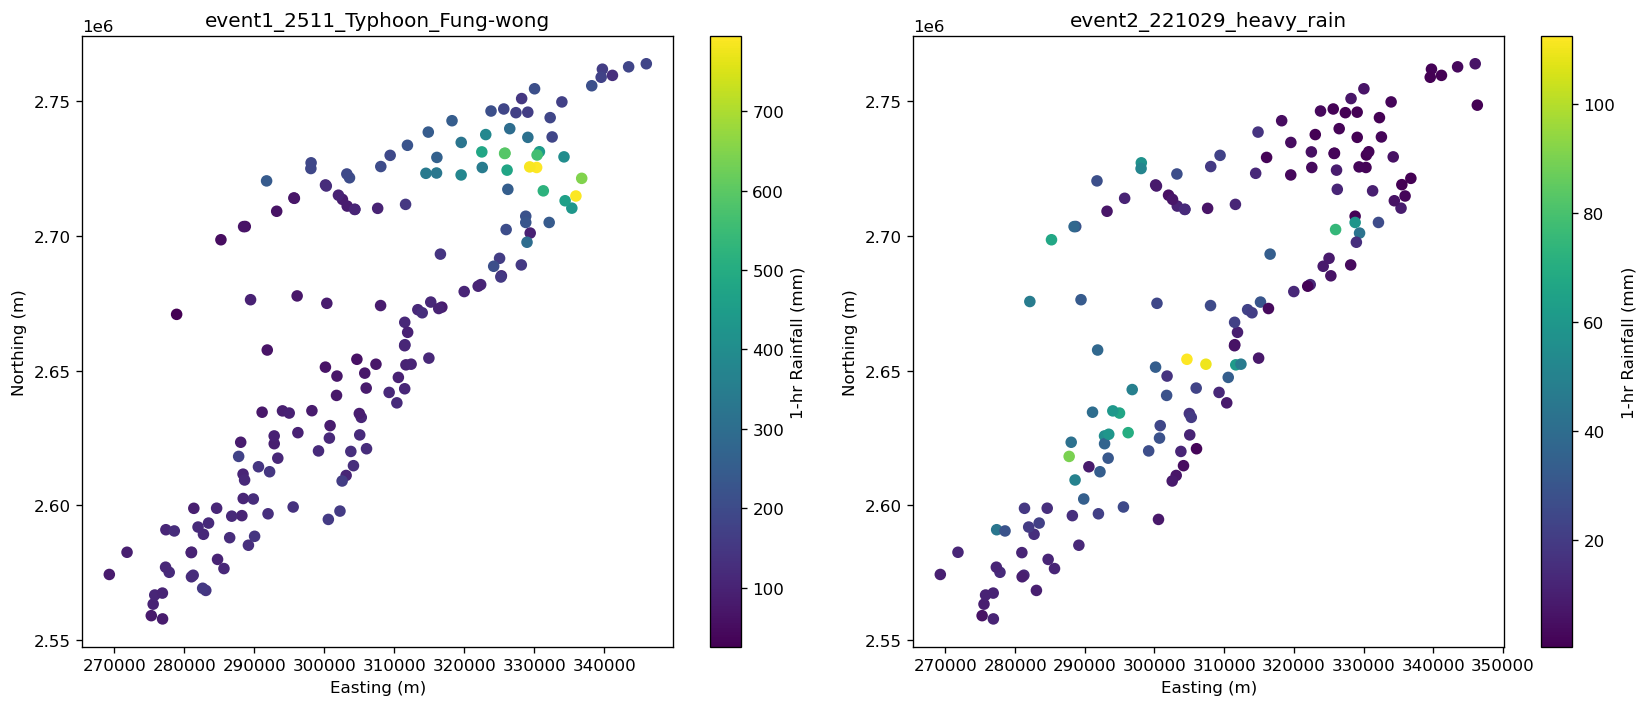

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gdf, title in zip(axes, [gdf1, gdf2], [EVENT1_NAME, EVENT2_NAME]):
    sc = ax.scatter(
        gdf.geometry.x, gdf.geometry.y,
        c=gdf["rain_24hr"], s=35
    )
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    plt.colorbar(sc, ax=ax, label="1-hr Rainfall (mm)")

plt.tight_layout()
plt.show()

### Cell 6：建立 Variogram 輔助函式

In [6]:
def get_xy_z(gdf):
    x = gdf.geometry.x.values
    y = gdf.geometry.y.values
    z = gdf["rain_24hr"].values
    z_log = np.log1p(z)
    return x, y, z, z_log

def compute_variogram_curve(model, h, sill, rng, nugget):
    if model == "spherical":
        gamma = np.where(
            h <= rng,
            nugget + sill * (1.5 * h / rng - 0.5 * (h / rng) ** 3),
            nugget + sill
        )
    elif model == "exponential":
        gamma = nugget + sill * (1 - np.exp(-h / rng))
    else:
        raise ValueError("Unsupported model")
    return gamma

def fit_ok(x, y, z_log, model="spherical", rng=50000, nlags=15):
    sill = float(np.var(z_log))
    nugget = float(np.var(z_log) * 0.1)

    ok = OrdinaryKriging(
        x, y, z_log,
        variogram_model=model,
        nlags=nlags,
        verbose=False,
        enable_plotting=False,
        variogram_parameters={
            "sill": sill,
            "range": rng,
            "nugget": nugget
        }
    )
    return ok

def variogram_sse(ok):
    params = ok.variogram_model_parameters
    sill, rng, nugget = params[0], params[1], params[2]
    fitted = compute_variogram_curve(ok.variogram_model, ok.lags, sill, rng, nugget)
    sse = np.sum((ok.semivariance - fitted) ** 2)
    return fitted, sse, sill, rng, nugget

### Cell 7：A1 Variogram 分析函式

每個事件至少比較兩種 variogram model，並說明最佳模型與參數差異。

In [7]:
def compare_variograms_for_event(gdf, event_name, range_m=50000):
    x, y, z, z_log = get_xy_z(gdf)

    models = ["spherical", "exponential"]
    rows = []

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, model in zip(axes, models):
        ok = fit_ok(x, y, z_log, model=model, rng=range_m, nlags=15)
        fitted, sse, sill, rng, nugget = variogram_sse(ok)

        ax.scatter(ok.lags / 1000, ok.semivariance, c="red", label="Empirical")
        ax.plot(ok.lags / 1000, fitted, "k-", lw=2, label="Fitted")
        ax.set_title(f"{event_name}\n{model.capitalize()} variogram")
        ax.set_xlabel("Distance (km)")
        ax.set_ylabel("Semivariance")
        ax.grid(True)
        ax.legend()

        rows.append({
            "event": event_name,
            "model": model,
            "sill": sill,
            "range_m": rng,
            "nugget": nugget,
            "SSE": sse
        })

    plt.tight_layout()
    plt.show()

    df = pd.DataFrame(rows).sort_values("SSE").reset_index(drop=True)
    return df

### Cell 8：執行兩事件 Variogram 比較

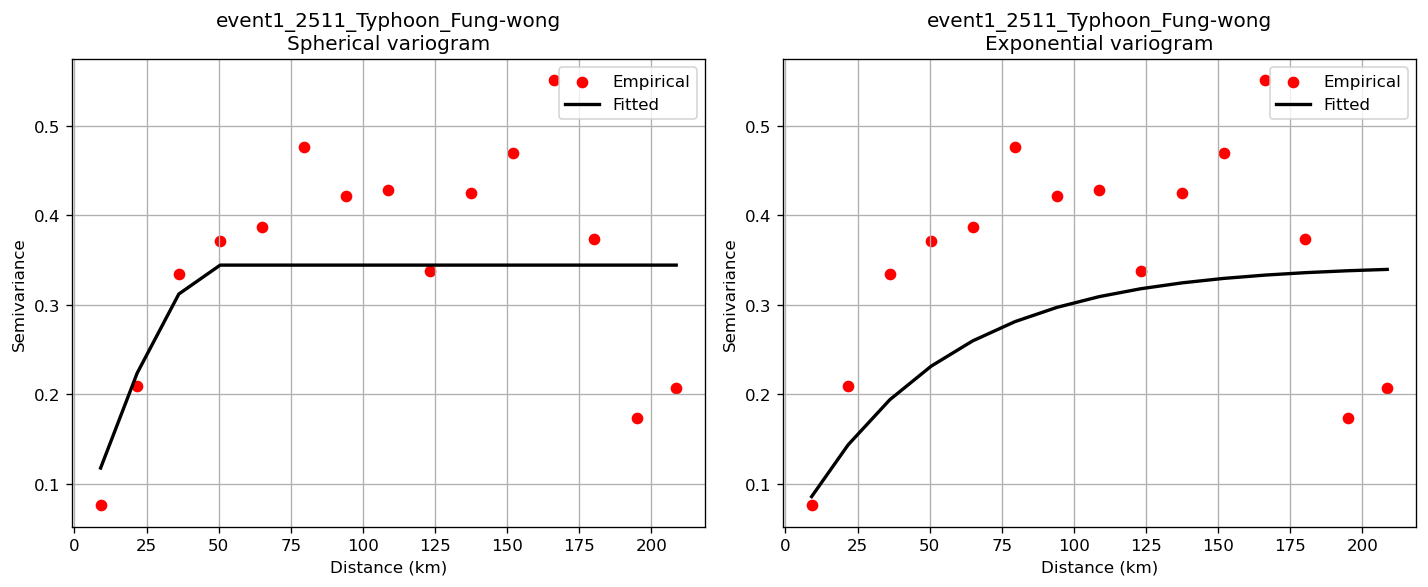

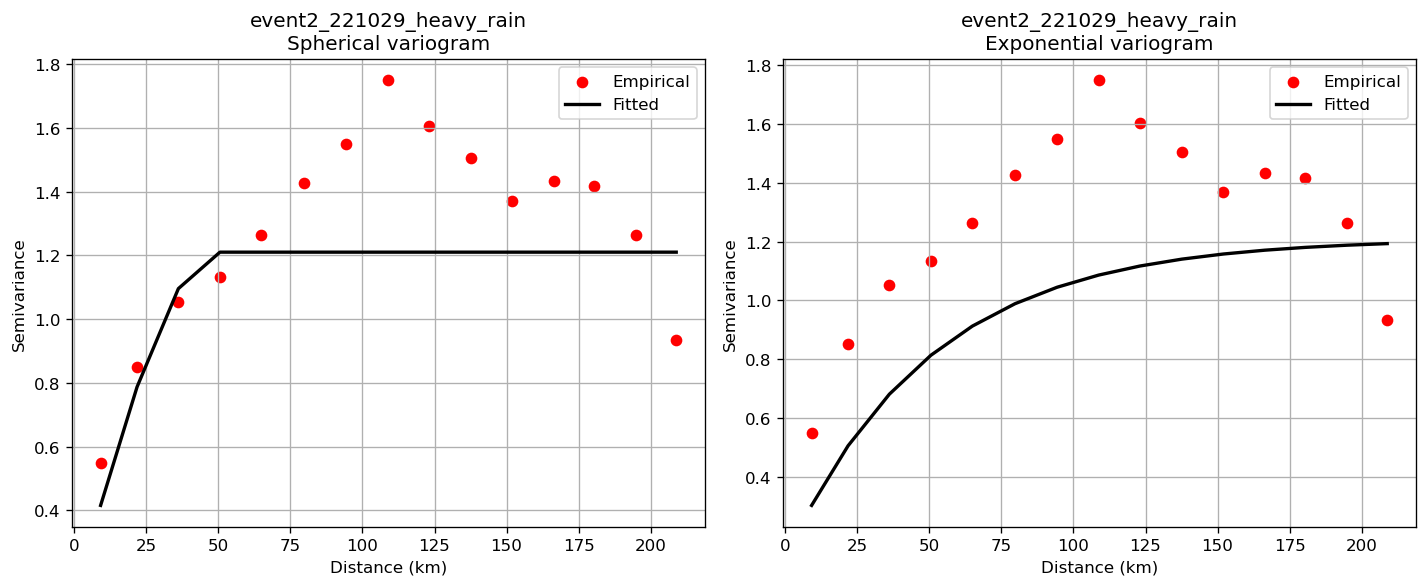

=== Event 1 Variogram Summary ===


,event,model,sill,range_m,nugget,SSE
0,event1_2511_Typhoon_Fung-wong,spherical,0.309725,50000,0.034414,0.148895
1,event1_2511_Typhoon_Fung-wong,exponential,0.309725,50000,0.034414,0.250619


=== Event 2 Variogram Summary ===


,event,model,sill,range_m,nugget,SSE
0,event2_221029_heavy_rain,spherical,1.088964,50000,0.120996,0.925478
1,event2_221029_heavy_rain,exponential,1.088964,50000,0.120996,2.042282


In [8]:
vario1 = compare_variograms_for_event(gdf1, EVENT1_NAME, range_m=50000)
vario2 = compare_variograms_for_event(gdf2, EVENT2_NAME, range_m=50000)

print("=== Event 1 Variogram Summary ===")
display(vario1)

print("=== Event 2 Variogram Summary ===")
display(vario2)

### Cell 9：最佳模型選擇與文字說明

In [9]:
best1 = vario1.iloc[0]
best2 = vario2.iloc[0]

print("事件1最佳模型：")
print(best1)

print("\n事件2最佳模型：")
print(best2)

事件1最佳模型：
event      event1_2511_Typhoon_Fung-wong
model                          spherical
sill                            0.309725
range_m                            50000
nugget                          0.034414
SSE                             0.148895
Name: 0, dtype: object

事件2最佳模型：
event      event2_221029_heavy_rain
model                     spherical
sill                       1.088964
range_m                       50000
nugget                     0.120996
SSE                        0.925478
Name: 0, dtype: object


事件 1 最佳 variogram 模型為 spherical，
因為其 SSE 最小，代表模型曲線與 empirical variogram 的吻合度較佳。

事件 2 最佳 variogram 模型為 spherical，
同樣是因為其 SSE 較低，表示較能反映該事件的空間自相關結構。

比較兩事件參數時，可觀察 sill、range、nugget 的差異：
sill 反映整體降雨變異程度，range 代表空間相關距離，
nugget 則可能與量測誤差或局部微尺度差異有關。

### Cell 10：四種內插共用函式

四種方法：NN、IDW、Ordinary Kriging、Random Forest，並使用 1000m 網格。

In [10]:
def make_grid(x, y, buffer_m=5000, resolution=1000):
    x_min = x.min() - buffer_m
    x_max = x.max() + buffer_m
    y_min = y.min() - buffer_m
    y_max = y.max() + buffer_m

    grid_x = np.arange(x_min, x_max, resolution)
    grid_y = np.arange(y_min, y_max, resolution)

    grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
    return x_min, x_max, y_min, y_max, grid_x, grid_y, grid_xx, grid_yy

def interpolate_all_methods(gdf, best_model):
    x, y, z, z_log = get_xy_z(gdf)
    x_min, x_max, y_min, y_max, grid_x, grid_y, grid_xx, grid_yy = make_grid(x, y)

    # NN
    nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
    z_nn = nn_interp(grid_xx, grid_yy)

    # IDW
    pts = np.column_stack([x, y])
    grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
    dists = cdist(grid_pts, pts)
    dists[dists < 1] = 1
    weights = 1 / dists**2
    weights /= weights.sum(axis=1, keepdims=True)
    z_idw = (weights @ z).reshape(grid_xx.shape)

    # Kriging
    ok = fit_ok(
        x, y, z_log,
        model=best_model["model"],
        rng=float(best_model["range_m"]),
        nlags=15
    )
    z_kriging_log, ss_kriging_log = ok.execute("grid", grid_x, grid_y)
    z_kriging = np.expm1(z_kriging_log)

    # RF
    X_train = np.column_stack([x, y])
    y_train = z
    rf = RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=3,
        random_state=42
    )
    rf.fit(X_train, y_train)
    z_rf = rf.predict(np.column_stack([grid_xx.ravel(), grid_yy.ravel()])).reshape(grid_xx.shape)

    return {
        "x": x, "y": y, "z": z,
        "x_min": x_min, "x_max": x_max, "y_min": y_min, "y_max": y_max,
        "grid_x": grid_x, "grid_y": grid_y,
        "grid_xx": grid_xx, "grid_yy": grid_yy,
        "z_nn": z_nn,
        "z_idw": z_idw,
        "z_kriging": z_kriging,
        "ss_kriging_log": ss_kriging_log,
        "z_rf": z_rf,
        "rf_model": rf
    }

### Cell 11：四種方法內插

In [11]:
res1 = interpolate_all_methods(gdf1, best1)
res2 = interpolate_all_methods(gdf2, best2)

print("兩事件內插完成。")

兩事件內插完成。


### Cell 12：A2 四圖並列

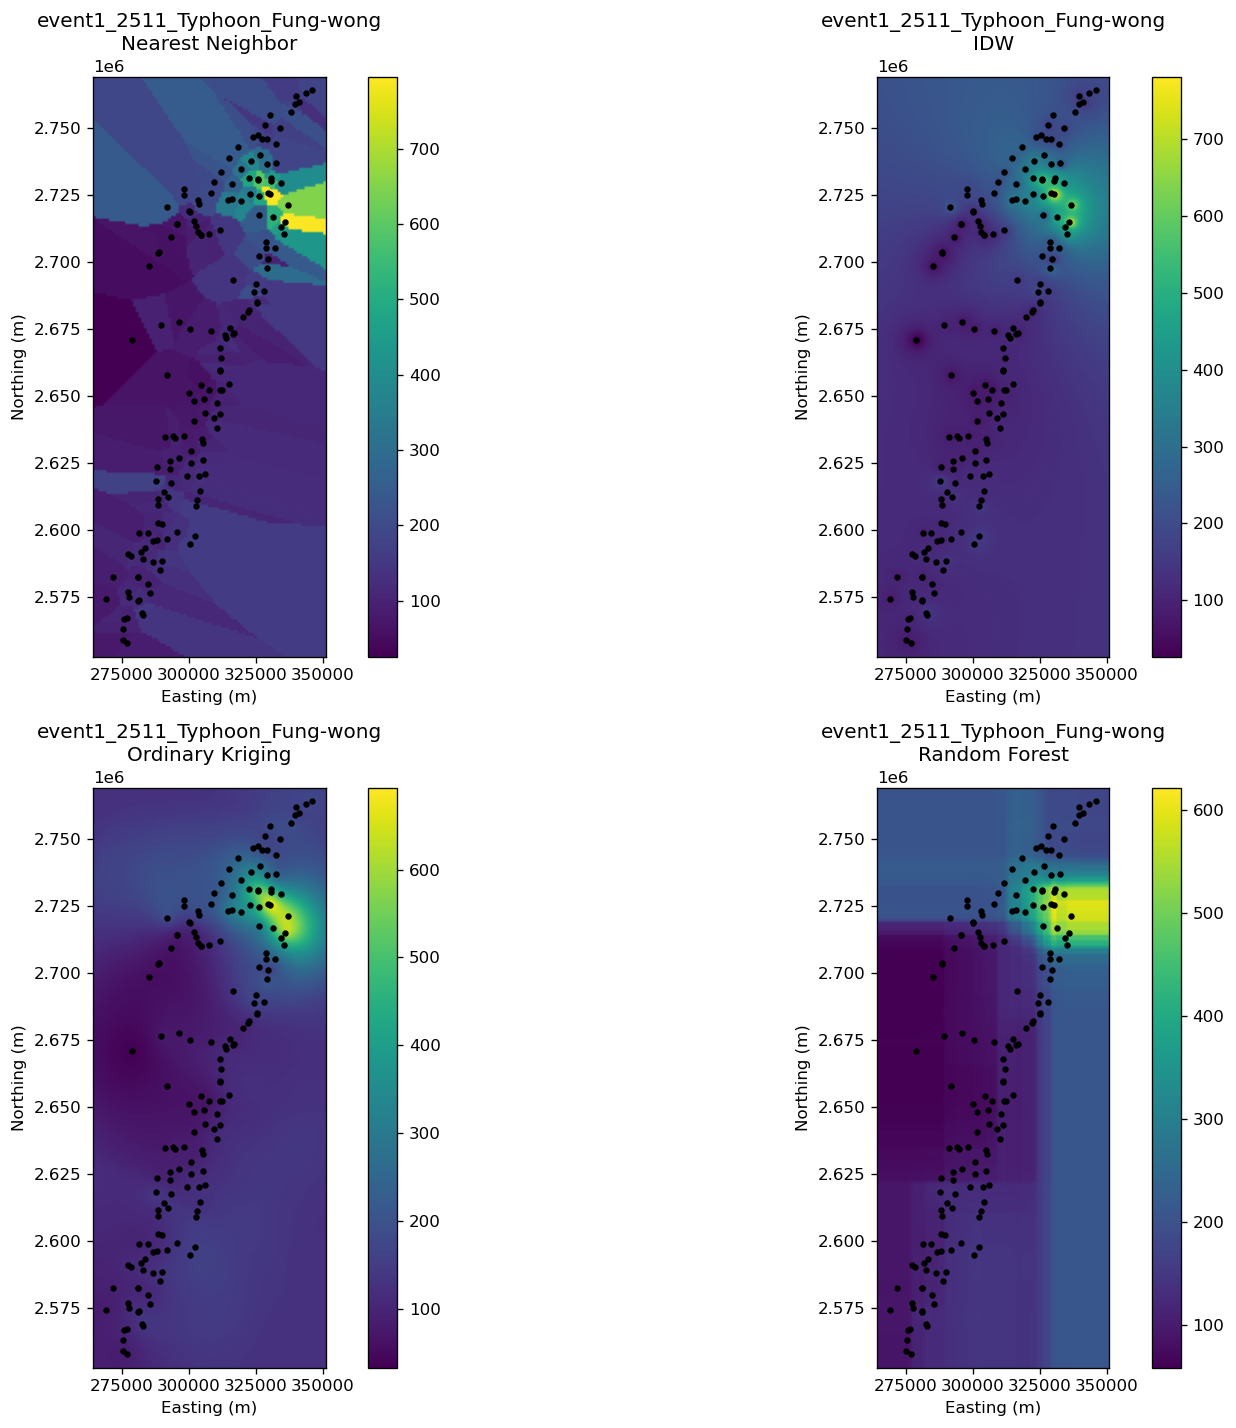

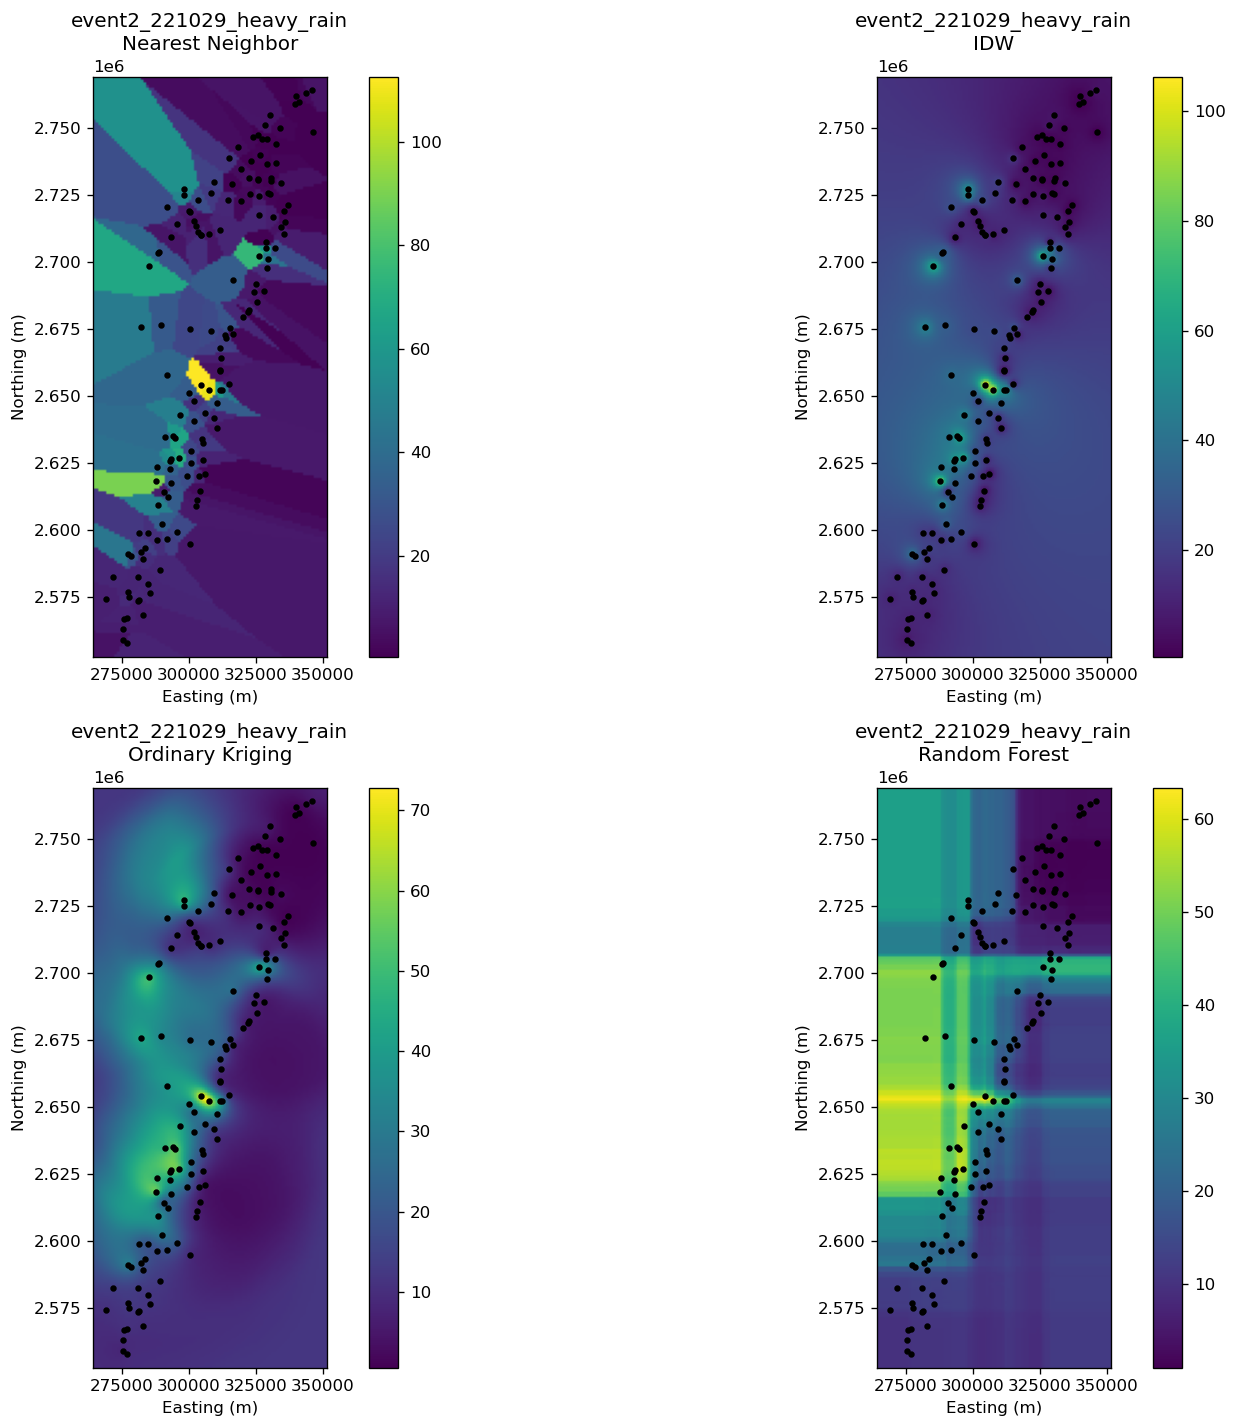

In [12]:
def plot_four_way(res, event_name):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    maps = [res["z_nn"], res["z_idw"], res["z_kriging"], res["z_rf"]]
    titles = ["Nearest Neighbor", "IDW", "Ordinary Kriging", "Random Forest"]

    for ax, data, title in zip(axes.ravel(), maps, titles):
        im = ax.imshow(
            data,
            extent=[res["x_min"], res["x_max"], res["y_min"], res["y_max"]],
            origin="lower"
        )
        ax.scatter(res["x"], res["y"], c="black", s=8)
        ax.set_title(f"{event_name}\n{title}")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

plot_four_way(res1, EVENT1_NAME)
plot_four_way(res2, EVENT2_NAME)

### Cell 13：A2 Kriging vs RF 差異圖

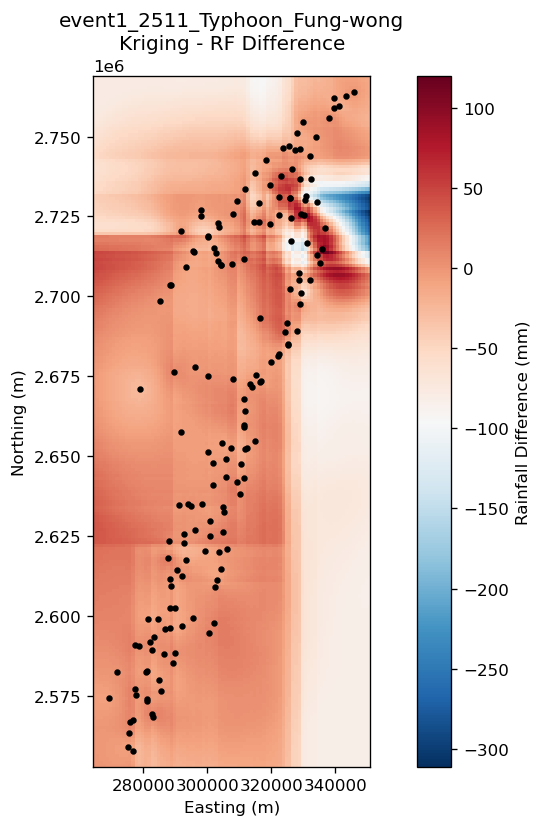

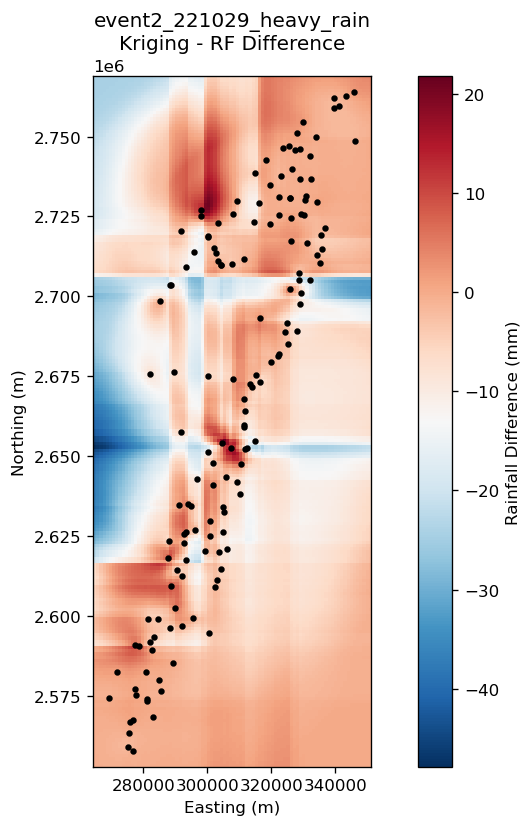

In [13]:
def plot_kriging_rf_diff(res, event_name):
    diff = res["z_kriging"] - res["z_rf"]

    plt.figure(figsize=(8, 7))
    im = plt.imshow(
        diff,
        extent=[res["x_min"], res["x_max"], res["y_min"], res["y_max"]],
        origin="lower",
        cmap="RdBu_r"
    )
    plt.scatter(res["x"], res["y"], c="black", s=8)
    plt.title(f"{event_name}\nKriging - RF Difference")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.colorbar(im, label="Rainfall Difference (mm)")
    plt.tight_layout()
    plt.show()

plot_kriging_rf_diff(res1, EVENT1_NAME)
plot_kriging_rf_diff(res2, EVENT2_NAME)

### Cell 14：A3 Sigma Map

作業要求用 Blues colormap 顯示 Kriging variance。

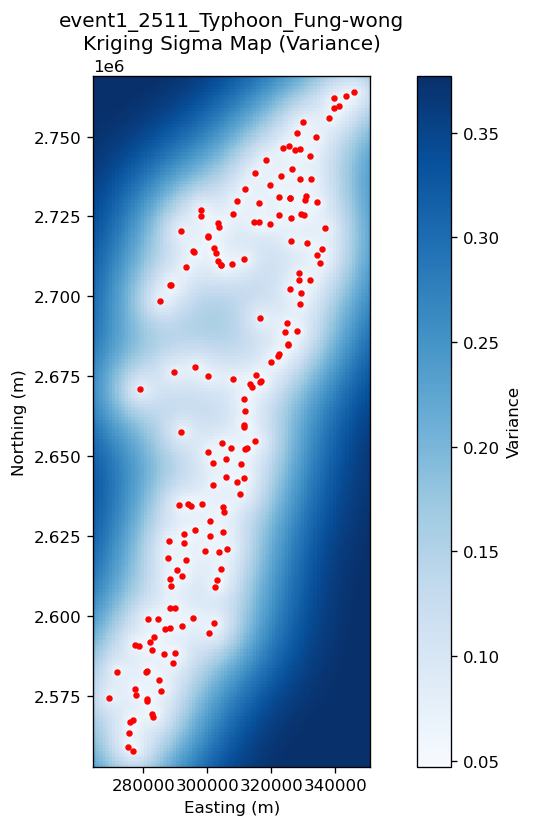

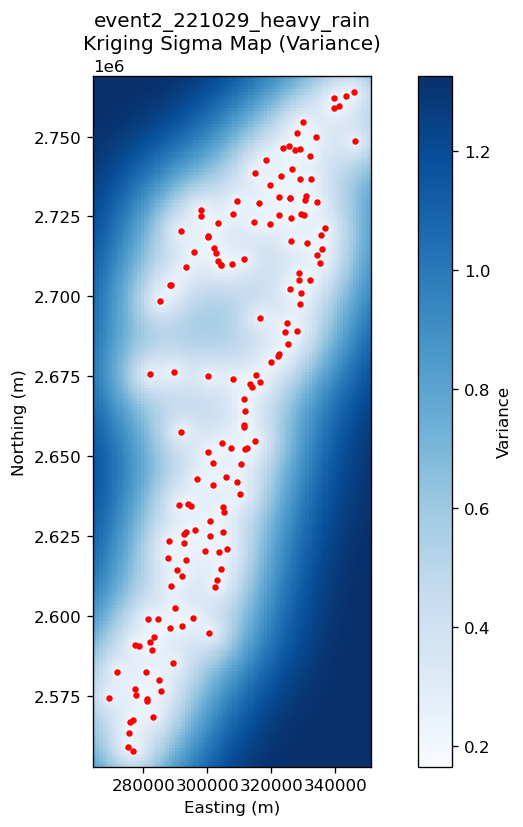

In [14]:
def plot_sigma_map(res, event_name):
    plt.figure(figsize=(8, 7))
    im = plt.imshow(
        res["ss_kriging_log"],
        extent=[res["x_min"], res["x_max"], res["y_min"], res["y_max"]],
        origin="lower",
        cmap="Blues"
    )
    plt.scatter(res["x"], res["y"], c="red", s=8)
    plt.title(f"{event_name}\nKriging Sigma Map (Variance)")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.colorbar(im, label="Variance")
    plt.tight_layout()
    plt.show()

plot_sigma_map(res1, EVENT1_NAME)
plot_sigma_map(res2, EVENT2_NAME)

## 比較分析
*** 
兩個事件的 Sigma Map 可能會呈現不同型態。若某事件的測站周圍降雨分布較一致，
且空間自相關較穩定，則 Kriging variance 通常較低；反之，若事件具有局部極端降雨、
測站稀疏或空間變化劇烈，Sigma Map 會出現較高的不確定性區域。

一般而言，降雨分布較平滑、較均勻的事件，Kriging 的預測信心通常較高；
而高度集中、強對流或受局部地形強烈影響的事件，預測不確定性會較高。

若我是指揮官，在高 variance 區域不會直接完全相信單一預測值，
而會把它視為需要補充情資的警示區，例如優先查核雷達、現地通報或歷史高風險地形。

Random Forest 雖然能提供預測結果，但本身不像 Kriging 那樣原生提供空間統計意義下的不確定性資訊，
因此在指揮決策上，Kriging 的 variance map 更具有風險溝通價值。
*** 

### Cell 16：A4 GeoTIFF 輸出

作業要求擇一事件輸出 kriging_rainfall.tif、kriging_variance.tif、rf_rainfall.tif，且需注意 np.flipud()。

In [15]:
def save_geotiff(data, filename, x_min, y_min, x_max, y_max):
    transform = from_bounds(
        x_min, y_min, x_max, y_max,
        data.shape[1], data.shape[0]
    )

    with rasterio.open(
        filename,
        "w",
        driver="GTiff",
        height=data.shape[0],
        width=data.shape[1],
        count=1,
        dtype=np.array(data).dtype,
        crs="EPSG:3826",
        transform=transform
    ) as dst:
        dst.write(np.flipud(np.array(data)), 1)

# 擇一事件輸出，這裡示範事件1
save_geotiff(
    res1["z_kriging"],
    "kriging_rainfall.tif",
    res1["x_min"], res1["y_min"], res1["x_max"], res1["y_max"]
)

save_geotiff(
    res1["ss_kriging_log"],
    "kriging_variance.tif",
    res1["x_min"], res1["y_min"], res1["x_max"], res1["y_max"]
)

save_geotiff(
    res1["z_rf"],
    "rf_rainfall.tif",
    res1["x_min"], res1["y_min"], res1["x_max"], res1["y_max"]
)

print("GeoTIFF export completed.")

GeoTIFF export completed.


### Cell 17：A5 整理兩事件的 Variogram 參數差異與最佳模型

In [16]:
bonus_table = pd.DataFrame({
    "參數": ["Sill", "Range", "Nugget", "Best Model"],
    "事件1": [
        best1["sill"],
        best1["range_m"],
        best1["nugget"],
        best1["model"]
    ],
    "事件2": [
        best2["sill"],
        best2["range_m"],
        best2["nugget"],
        best2["model"]
    ],
    "差異原因": [
        "反映整體降雨變異程度差異",
        "反映空間影響距離差異",
        "可能與量測誤差或局部微尺度差異有關",
        "代表不同事件更適合不同空間自相關假設"
    ]
})

display(bonus_table)

,參數,事件1,事件2,差異原因
0,Sill,0.309725,1.088964,反映整體降雨變異程度差異
1,Range,50000,50000,反映空間影響距離差異
2,Nugget,0.034414,0.120996,可能與量測誤差或局部微尺度差異有關
3,Best Model,spherical,spherical,代表不同事件更適合不同空間自相關假設


如果只能用一組 Variogram 參數套用到未來所有事件，
我會傾向選擇在歷史事件中表現相對穩定、且對多數事件都不算太差的參數組合作為折衷方案。

但這樣做有很大風險，因為不同降雨事件的空間分布特性不同。
例如集中型颱風降雨與均勻型梅雨降雨，對應的 sill、range 與 nugget 可能差很多。
若硬套同一組參數，可能導致某些事件被過度平滑，或錯估局部極端降雨區域。
因此 Variogram 應盡量依事件特性重新評估，而不是完全固定。

本次作業比較了兩個不同降雨事件的空間預測結果。
在 Variogram 分析中，不同事件呈現不同的 sill、range 與 nugget，
顯示降雨型態會直接影響空間自相關結構。

四種方法比較中，Nearest Neighbor 與 IDW 較偏向幾何距離延伸，
Kriging 則納入空間統計結構，並能提供 variance map，
對災害決策特別重要。
Random Forest 能學習非線性空間模式，但若只使用座標作為特徵，
其可解釋性與不確定性資訊仍不如 Kriging。

因此，若目標是指揮決策與風險溝通，我會優先採用 Kriging，
並以 Random Forest 作為輔助比較模型。